## Tasks
The task is to investigate the chemical utilization of $CO_2$ in form of hydrocarbons by hydrogenation. For simplicity, methane is chosen as desired products. The task is to determine the thermodynamic properties function of temperature. The relevant stoichiometric equations taking place in principle are:

\begin{align}
CO_2 + 4H_2 &\rightleftharpoons CH_4 + 2H_2O\\
CO_2 + H_2 &\rightleftharpoons CO + H_2O\\
CO + 3H_2 &\rightleftharpoons CH_4 + H_2O
\end{align}

In order to fulfill the assignment, the following tasks should be achieved:
* research required information, e.g. meaningful reaction conditions, thermodynamic data, data for validation
* brief discussion of the mathematical approach and the implementation to Python, if adapted with respect to the example above

Regarding thermodynamic data, we suggest the following data bases:
- [1] NASA database: https://ntrs.nasa.gov/citations/20020085330
- Shomate equations,
[2] NIST database: https://webbook.nist.gov/chemistry/
- search for compound
- Shomate equation and parameters summarized under "Gas phase thermochemistry data"

### Glenn Equation

$$
\frac{C_{p}^{\circ}(T)}{R}
= a_1 T^{-2}
+ a_2 T^{-1}
+ a_3
+ a_4 T
+ a_5 T^2
+ a_6 T^3
+ a_7 T^4
$$

$$
\frac{H^\circ(T)}{RT}
= -a_1 T^{-2}
+ \frac{a_2 \ln T}{T}
+ a_3
+ \frac{a_4 T}{2}
+ \frac{a_5 T^2}{3}
+ \frac{a_6 T^3}{4}
+ \frac{a_7 T^4}{5}
+ \frac{b_1}{T}
$$

$$
\frac{S^\circ(T)}{R}
= -\frac{a_1 T^{-2}}{2}
- a_2 T^{-1}
+ a_3 \ln T
+ a_4 T
+ \frac{a_5 T^2}{2}
+ \frac{a_6 T^3}{3}
+ \frac{a_7 T^4}{4}
+ b_2
$$

### Shomate Equation

$$
C_p^\circ
= A
+ B \cdot t
+ C \cdot t^2
+ D \cdot t^3
+ \frac{E}{t^2}
$$

$$
H^\circ - H^\circ_{298.15}
= A \cdot t
+ \frac{B \cdot t^2}{2}
+ \frac{C \cdot t^3}{3}
+ \frac{D \cdot t^4}{4}
- \frac{E}{t}
+ F
- H
$$

$$
S^\circ
= A \cdot \ln(t)
+ B \cdot t
+ \frac{C \cdot t^2}{2}
+ \frac{D \cdot t^3}{3}
- \frac{E}{2 \cdot t^2}
+ G
$$

Shomate parameters for species:

| Component | Temperature range / K | A | B | C | D | E | F | G | H |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| $CO_2$ | 298–1200 | 24.99735 | 55.18696 | -33.69137 | 7.948387 | -0.136638 | -403.6075 | 228.2431 | -393.5224 |
| $CO_2$ | 1200–6000 | 58.16639 | 2.720074 | -0.492289 | 0.038844 | -6.447293 | -425.9186 | 263.6125 | -393.5224 |
| $H_2$ | 298–1000 | 33.066178 | -11.363417 | 11.432816 | -2.772874 | -0.158558 | -9.980797 | 172.707974 | 0.0 |
| $H_2$ | 1000–2500 | 18.563083 | 12.257357 | -2.859786 | 0.268238 | 1.977990 | -1.147438 | 156.288133 | 0.0 |
| $H_2$ | 2500–6000 | 43.413560 | -4.293079 | 1.272428 | -0.096876 | -20.533862 | -38.515158 | 162.081354 | 0.0 |
| $CH_4$ | 298–1300 | -0.703029 | 108.4773 | -42.52157 | 5.862788 | 0.678565 | -76.84376 | 158.7163 | -74.87310 |
| $CH_4$ | 1300–6000 | 85.81217 | 11.26467 | -2.114146 | 0.138190 | -26.42221 | -153.5327 | 224.4143 | -74.87310 |
| $H_2O$ | 500–1700 | 30.09200 | 6.832514 | 6.793435 | -2.534480 | 0.082139 | -250.8810 | 223.3967 | -241.8264 |
| $H_2O$ | 1700–6000 | 41.96426 | 8.622053 | -1.499780 | 0.098119 | -11.15764 | -272.1797 | 219.7809 | -241.8264 |
| $CO$ | 298–1300 | 25.56759 | 6.096130 | 4.054656 | -2.671301 | 0.131021 | -118.0089 | 227.3665 | -110.5271 |
| $CO$ | 1300–6000 | 35.15070 | 1.300095 | -0.205921 | 0.013550 | -3.282780 | -127.8375 | 231.7120 | -110.5271 |

For the Shomate gas phase data $H = H^\circ$

Functions that calculate $c_p, H$ and $S$ using the Shomate equations

In [12]:
# imports
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def cp_shomate(T, A, B, C, D, E, F=None, G=None, H=None, T_min=None, T_max=None):
    """
    Calculates Cp° using the Shomate equation.

    T in K
    Cp° in J/(mol*K)
    """
    t = np.asarray(T) / 1000

    Cp = (
        A
        + B * t
        + C * t**2
        + D * t**3
        + E / t**2
    )

    return Cp


def h_shomate(T, A, B, C, D, E, F, G=None, H=0, T_min=None, T_max=None):
    """
    Calculates H°(T) - H°(298.15 K).

    For Shomate gas phase data:
    H parameter corresponds to H° at 298.15 K.

    T in K
    H° - H°298.15 in kJ/mol
    """
    t = np.asarray(T) / 1000

    delta_H = (
        A * t
        + B * t**2 / 2
        + C * t**3 / 3
        + D * t**4 / 4
        - E / t
        + F
        - H
    )

    return delta_H


def s_shomate(T, A, B, C, D, E, F=None, G=None, H=None, T_min=None, T_max=None):
    """
    Calculates S° using the Shomate equation.

    T in K
    S° in J/(mol*K)
    """
    t = np.asarray(T) / 1000

    S = (
        A * np.log(t)
        + B * t
        + C * t**2 / 2
        + D * t**3 / 3
        - E / (2 * t**2)
        + G
    )

    return S

Import of gas phase Shomate coefficients 

In [14]:

shomate_data = {
    "CO2": [
        {
            "T_min": 298,
            "T_max": 1200,
            "A": 24.99735,
            "B": 55.18696,
            "C": -33.69137,
            "D": 7.948387,
            "E": -0.136638,
            "F": -403.6075,
            "G": 228.2431,
            "H": -393.5224,
        },
        {
            "T_min": 1200,
            "T_max": 6000,
            "A": 58.16639,
            "B": 2.720074,
            "C": -0.492289,
            "D": 0.038844,
            "E": -6.447293,
            "F": -425.9186,
            "G": 263.6125,
            "H": -393.5224,
        },
    ],

    "H2": [
        {
            "T_min": 298,
            "T_max": 1000,
            "A": 33.066178,
            "B": -11.363417,
            "C": 11.432816,
            "D": -2.772874,
            "E": -0.158558,
            "F": -9.980797,
            "G": 172.707974,
            "H": 0.0,
        },
        {
            "T_min": 1000,
            "T_max": 2500,
            "A": 18.563083,
            "B": 12.257357,
            "C": -2.859786,
            "D": 0.268238,
            "E": 1.977990,
            "F": -1.147438,
            "G": 156.288133,
            "H": 0.0,
        },
        {
            "T_min": 2500,
            "T_max": 6000,
            "A": 43.413560,
            "B": -4.293079,
            "C": 1.272428,
            "D": -0.096876,
            "E": -20.533862,
            "F": -38.515158,
            "G": 162.081354,
            "H": 0.0,
        },
    ],

    "CH4": [
        {
            "T_min": 298,
            "T_max": 1300,
            "A": -0.703029,
            "B": 108.4773,
            "C": -42.52157,
            "D": 5.862788,
            "E": 0.678565,
            "F": -76.84376,
            "G": 158.7163,
            "H": -74.87310,
        },
        {
            "T_min": 1300,
            "T_max": 6000,
            "A": 85.81217,
            "B": 11.26467,
            "C": -2.114146,
            "D": 0.138190,
            "E": -26.42221,
            "F": -153.5327,
            "G": 224.4143,
            "H": -74.87310,
        },
    ],

    "H2O": [
        {
            "T_min": 500,
            "T_max": 1700,
            "A": 30.09200,
            "B": 6.832514,
            "C": 6.793435,
            "D": -2.534480,
            "E": 0.082139,
            "F": -250.8810,
            "G": 223.3967,
            "H": -241.8264,
        },
        {
            "T_min": 1700,
            "T_max": 6000,
            "A": 41.96426,
            "B": 8.622053,
            "C": -1.499780,
            "D": 0.098119,
            "E": -11.15764,
            "F": -272.1797,
            "G": 219.7809,
            "H": -241.8264,
        },
    ],

    "CO": [
        {
            "T_min": 298,
            "T_max": 1300,
            "A": 25.56759,
            "B": 6.096130,
            "C": 4.054656,
            "D": -2.671301,
            "E": 0.131021,
            "F": -118.0089,
            "G": 227.3665,
            "H": -110.5271,
        },
        {
            "T_min": 1300,
            "T_max": 6000,
            "A": 35.15070,
            "B": 1.300095,
            "C": -0.205921,
            "D": 0.013550,
            "E": -3.282780,
            "F": -127.8375,
            "G": 231.7120,
            "H": -110.5271,
        },
    ],
}

Function to get the correct Shomate parameters for a given species and temperature

In [15]:
def get_shomate_parameters(species, T):
    """
    Returns the Shomate parameter set for a given species and temperature.

    Parameters
    ----------
    species : str
        Species name, e.g. "CO2", "H2", "CH4", "H2O", "CO"
    T : float
        Temperature in K

    Returns
    -------
    params : dict
        Shomate parameters for the valid temperature range
    """
    if species not in shomate_data:
        raise ValueError(f"Species '{species}' is not available.")

    for params in shomate_data[species]:
        if params["T_min"] <= T <= params["T_max"]:
            return params

    raise ValueError(
        f"No Shomate parameters available for {species} at T = {T} K."
    )

Wrapper functions for easy acces to all parameters

In [16]:
def cp_species(species, T):
    """
    Calculates Cp° for a given species at temperature T.

    Returns Cp° in J/(mol*K).
    """
    params = get_shomate_parameters(species, T)
    return cp_shomate(T, **params)


def h_species(species, T):
    """
    Calculates H°(T) - H°(298.15 K) for a given species.

    Returns enthalpy difference in kJ/mol.
    """
    params = get_shomate_parameters(species, T)
    return h_shomate(T, **params)


def s_species(species, T):
    """
    Calculates S° for a given species at temperature T.

    Returns S° in J/(mol*K).
    """
    params = get_shomate_parameters(species, T)
    return s_shomate(T, **params)

Calculating and plotting $c_p, H$ and $S$ for methane:

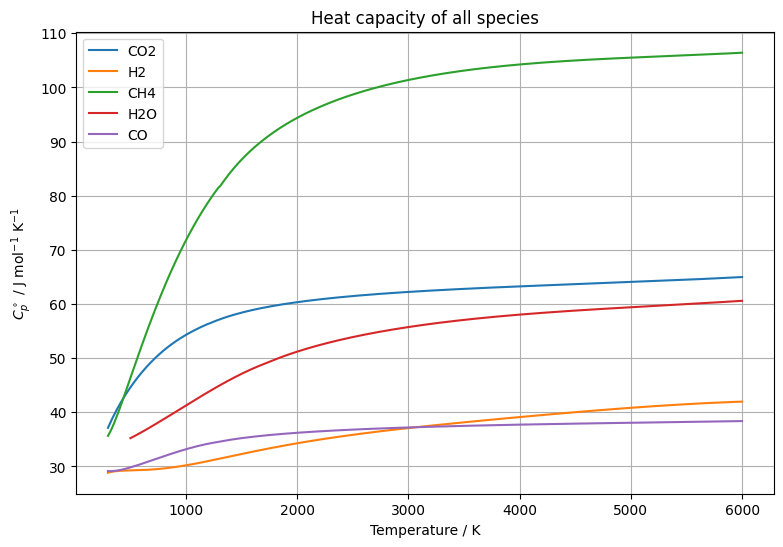

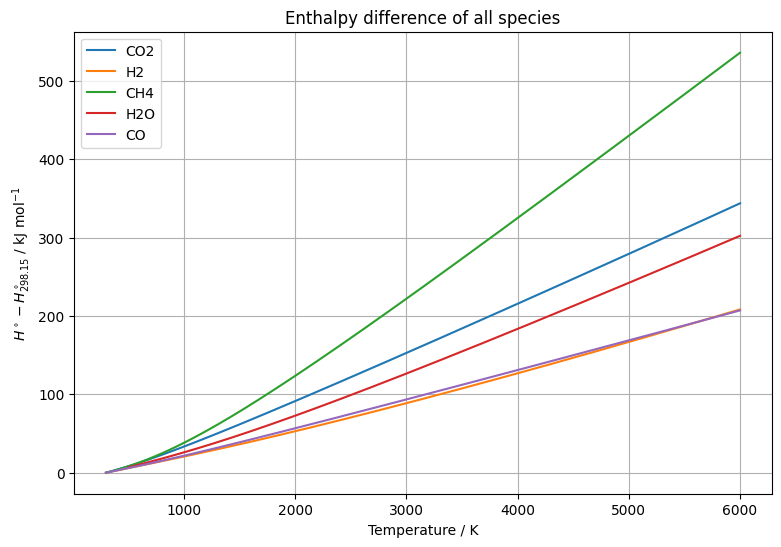

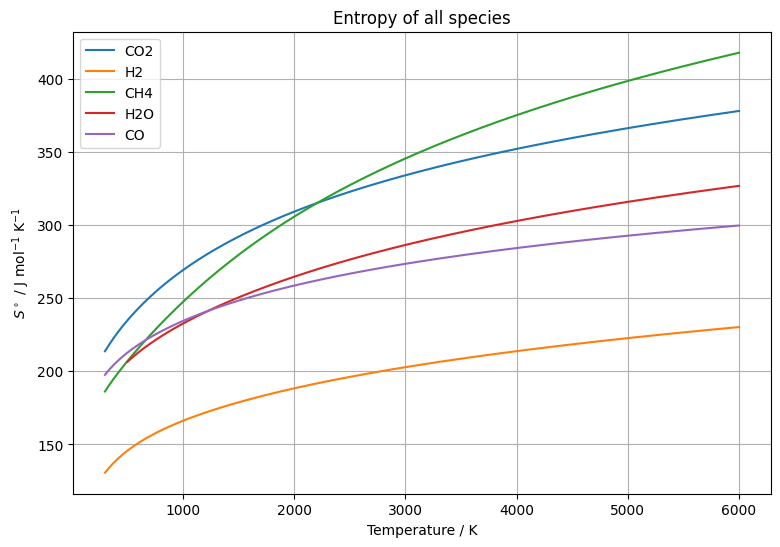

In [19]:
species_list = ["CO2", "H2", "CH4", "H2O", "CO"]

# Cp plot: all species
plt.figure(figsize=(9, 6))

for species in species_list:
    T_min = shomate_data[species][0]["T_min"]
    T_max = shomate_data[species][-1]["T_max"]

    T_range = np.linspace(T_min, T_max, 300)
    Cp = np.array([cp_species(species, T) for T in T_range])

    plt.plot(T_range, Cp, label=species)

plt.xlabel("Temperature / K")
plt.ylabel(r"$C_p^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Heat capacity of all species")
plt.grid(True)
plt.legend()
plt.show()


# H plot: all species
plt.figure(figsize=(9, 6))

for species in species_list:
    T_min = shomate_data[species][0]["T_min"]
    T_max = shomate_data[species][-1]["T_max"]

    T_range = np.linspace(T_min, T_max, 300)
    H = np.array([h_species(species, T) for T in T_range])

    plt.plot(T_range, H, label=species)

plt.xlabel("Temperature / K")
plt.ylabel(r"$H^\circ - H^\circ_{298.15}$ / kJ mol$^{-1}$")
plt.title(r"Enthalpy difference of all species")
plt.grid(True)
plt.legend()
plt.show()


# S plot: all species
plt.figure(figsize=(9, 6))

for species in species_list:
    T_min = shomate_data[species][0]["T_min"]
    T_max = shomate_data[species][-1]["T_max"]

    T_range = np.linspace(T_min, T_max, 300)
    S = np.array([s_species(species, T) for T in T_range])

    plt.plot(T_range, S, label=species)

plt.xlabel("Temperature / K")
plt.ylabel(r"$S^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Entropy of all species")
plt.grid(True)
plt.legend()
plt.show()

Data for 250°C

In [20]:
T_C = 250
T_K = T_C + 273.15

species_list = ["CO2", "H2", "CH4", "H2O", "CO"]

print(f"Thermodynamic data at {T_C} °C = {T_K:.2f} K")
print("-" * 75)
print(f"{'Species':<8} {'Cp° / J mol⁻¹ K⁻¹':>20} {'H°-H°298 / kJ mol⁻¹':>25} {'S° / J mol⁻¹ K⁻¹':>20}")
print("-" * 75)

for species in species_list:
    Cp = cp_species(species, T_K)
    H = h_species(species, T_K)
    S = s_species(species, T_K)

    print(f"{species:<8} {Cp:>20.4f} {H:>25.4f} {S:>20.4f}")

print("-" * 75)

Thermodynamic data at 250 °C = 523.15 K
---------------------------------------------------------------------------
Species     Cp° / J mol⁻¹ K⁻¹       H°-H°298 / kJ mol⁻¹     S° / J mol⁻¹ K⁻¹
---------------------------------------------------------------------------
CO2                   45.2863                    9.3463             236.9372
H2                    29.2740                    6.5596             147.0619
CH4                   47.7281                    9.2892             209.1430
H2O                   35.4629                    7.7428             208.1335
CO                    29.9627                    6.6211             214.1788
---------------------------------------------------------------------------


## Calculation of reaction enthalpy, entropy and Gibbs energy

The considered reaction is:

$$
CO_2 + 4H_2 \rightleftharpoons CH_4 + 2H_2O
$$

For a general reaction, the thermodynamic reaction properties are calculated from the stoichiometric sum of the products minus the stoichiometric sum of the reactants:

$$
\Delta_R X^\circ(T)
=
\sum_i \nu_i X_i^\circ(T)
$$

where $\nu_i$ is the stoichiometric coefficient. Products have positive coefficients and reactants have negative coefficients.

For the reaction

$$
CO_2 + 4H_2 \rightleftharpoons CH_4 + 2H_2O
$$

the stoichiometric coefficients are:

$$
\nu_{CO_2} = -1
$$

$$
\nu_{H_2} = -4
$$

$$
\nu_{CH_4} = +1
$$

$$
\nu_{H_2O} = +2
$$

---

## Reaction enthalpy

The reaction enthalpy is calculated as:

$$
\Delta_R H^\circ(T)
=
\sum_i \nu_i H_i^\circ(T)
$$

For this reaction:

$$
\Delta_R H^\circ(T)
=
H_{CH_4}^\circ(T)
+
2H_{H_2O}^\circ(T)
-
H_{CO_2}^\circ(T)
-
4H_{H_2}^\circ(T)
$$

Using the Shomate equation, the enthalpy function gives:

$$
H_i^\circ(T) - H_i^\circ(298.15)
$$

The absolute standard enthalpy at temperature $T$ is therefore:

$$
H_i^\circ(T)
=
\left[H_i^\circ(T) - H_i^\circ(298.15)\right]
+
H_i^\circ(298.15)
$$

For gas phase Shomate data:

$$
H_i^\circ(298.15) = H_i
$$

Therefore:

$$
H_i^\circ(T)
=
\Delta H_i^\circ(T)
+
H_i
$$

with:

$$
\Delta H_i^\circ(T)
=
A_i t
+
\frac{B_i t^2}{2}
+
\frac{C_i t^3}{3}
+
\frac{D_i t^4}{4}
-
\frac{E_i}{t}
+
F_i
-
H_i
$$

and:

$$
t = \frac{T}{1000}
$$

Thus, the reaction enthalpy becomes:

$$
\Delta_R H^\circ(T)
=
\left(\Delta H_{CH_4}^\circ(T) + H_{CH_4}\right)
+
2\left(\Delta H_{H_2O}^\circ(T) + H_{H_2O}\right)
-
\left(\Delta H_{CO_2}^\circ(T) + H_{CO_2}\right)
-
4\left(\Delta H_{H_2}^\circ(T) + H_{H_2}\right)
$$

The unit of $\Delta_R H^\circ(T)$ is:

$$
\mathrm{kJ\,mol^{-1}}
$$

---

## Reaction entropy

The reaction entropy is calculated as:

$$
\Delta_R S^\circ(T)
=
\sum_i \nu_i S_i^\circ(T)
$$

For this reaction:

$$
\Delta_R S^\circ(T)
=
S_{CH_4}^\circ(T)
+
2S_{H_2O}^\circ(T)
-
S_{CO_2}^\circ(T)
-
4S_{H_2}^\circ(T)
$$

The entropy of each component is calculated with the Shomate equation:

$$
S_i^\circ(T)
=
A_i \ln(t)
+
B_i t
+
\frac{C_i t^2}{2}
+
\frac{D_i t^3}{3}
-
\frac{E_i}{2t^2}
+
G_i
$$

with:

$$
t = \frac{T}{1000}
$$

The unit of $\Delta_R S^\circ(T)$ is:

$$
\mathrm{J\,mol^{-1}\,K^{-1}}
$$

For later use in the Gibbs energy equation, the entropy should be converted to:

$$
\mathrm{kJ\,mol^{-1}\,K^{-1}}
$$

Therefore:

$$
\Delta_R S^\circ(T)_{\mathrm{kJ}}
=
\frac{\Delta_R S^\circ(T)}{1000}
$$

---

## Reaction Gibbs energy

The Gibbs energy of reaction is calculated from:

$$
\Delta_R G^\circ(T)
=
\Delta_R H^\circ(T)
-
T \Delta_R S^\circ(T)
$$

Since $\Delta_R H^\circ(T)$ is usually given in $\mathrm{kJ\,mol^{-1}}$ and $\Delta_R S^\circ(T)$ in $\mathrm{J\,mol^{-1}\,K^{-1}}$, the entropy has to be divided by $1000$:

$$
\Delta_R G^\circ(T)
=
\Delta_R H^\circ(T)
-
T \cdot \frac{\Delta_R S^\circ(T)}{1000}
$$

For the considered reaction:

$$
\Delta_R G^\circ(T)
=
\left[
H_{CH_4}^\circ(T)
+
2H_{H_2O}^\circ(T)
-
H_{CO_2}^\circ(T)
-
4H_{H_2}^\circ(T)
\right]
-
T \cdot
\frac{
S_{CH_4}^\circ(T)
+
2S_{H_2O}^\circ(T)
-
S_{CO_2}^\circ(T)
-
4S_{H_2}^\circ(T)
}{1000}
$$

The unit of $\Delta_R G^\circ(T)$ is:

$$
\mathrm{kJ\,mol^{-1}}
$$

---

## At $T = 250°C$

The temperature in Kelvin is:

$$
T = 250 + 273.15 = 523.15\,\mathrm{K}
$$

Therefore, for this temperature:

$$
\Delta_R H^\circ(523.15\,\mathrm{K})
=
H_{CH_4}^\circ(523.15)
+
2H_{H_2O}^\circ(523.15)
-
H_{CO_2}^\circ(523.15)
-
4H_{H_2}^\circ(523.15)
$$

$$
\Delta_R S^\circ(523.15\,\mathrm{K})
=
S_{CH_4}^\circ(523.15)
+
2S_{H_2O}^\circ(523.15)
-
S_{CO_2}^\circ(523.15)
-
4S_{H_2}^\circ(523.15)
$$

$$
\Delta_R G^\circ(523.15\,\mathrm{K})
=
\Delta_R H^\circ(523.15\,\mathrm{K})
-
523.15
\cdot
\frac{\Delta_R S^\circ(523.15\,\mathrm{K})}{1000}
$$

Calculating absolute enthalpies

In [21]:
def h_abs_species(species, T):
    """
    Calculates absolute standard enthalpy H°(T).

    h_species(species, T) returns:
    H°(T) - H°(298.15 K)

    For gas phase Shomate data:
    H parameter = H°(298.15 K)

    Returns
    -------
    H_abs : float
        Absolute standard enthalpy in kJ/mol
    """
    params = get_shomate_parameters(species, T)

    delta_H = h_species(species, T)   # kJ/mol
    H_298 = params["H"]               # kJ/mol

    H_abs = delta_H + H_298

    return H_abs

defining all components of the reaction

In [22]:
# Reaction:
# CO2 + 4 H2 <-> CH4 + 2 H2O

reaction_1 = {
    "CO2": -1,
    "H2": -4,
    "CH4": 1,
    "H2O": 2
}

Calculating reaction enthalpie, entropy and gibbs energy

In [23]:
def reaction_enthalpy(reaction, T):
    """
    Calculates standard reaction enthalpy ΔR H°(T).

    Parameters
    ----------
    reaction : dict
        Stoichiometric coefficients.
        Products positive, reactants negative.
    T : float
        Temperature in K.

    Returns
    -------
    delta_H_R : float
        Reaction enthalpy in kJ/mol.
    """
    delta_H_R = 0

    for species, nu in reaction.items():
        delta_H_R += nu * h_abs_species(species, T)

    return delta_H_R


def reaction_entropy(reaction, T):
    """
    Calculates standard reaction entropy ΔR S°(T).

    Parameters
    ----------
    reaction : dict
        Stoichiometric coefficients.
        Products positive, reactants negative.
    T : float
        Temperature in K.

    Returns
    -------
    delta_S_R : float
        Reaction entropy in J/(mol*K).
    """
    delta_S_R = 0

    for species, nu in reaction.items():
        delta_S_R += nu * s_species(species, T)

    return delta_S_R


def reaction_gibbs(reaction, T):
    """
    Calculates standard Gibbs energy of reaction ΔR G°(T).

    Parameters
    ----------
    reaction : dict
        Stoichiometric coefficients.
        Products positive, reactants negative.
    T : float
        Temperature in K.

    Returns
    -------
    delta_G_R : float
        Gibbs energy of reaction in kJ/mol.
    """
    delta_H_R = reaction_enthalpy(reaction, T)      # kJ/mol
    delta_S_R = reaction_entropy(reaction, T)      # J/(mol*K)

    delta_G_R = delta_H_R - T * delta_S_R / 1000   # kJ/mol

    return delta_G_R

calculating and plotting enthalpies, entropies and gibbs energies for given temperature range:

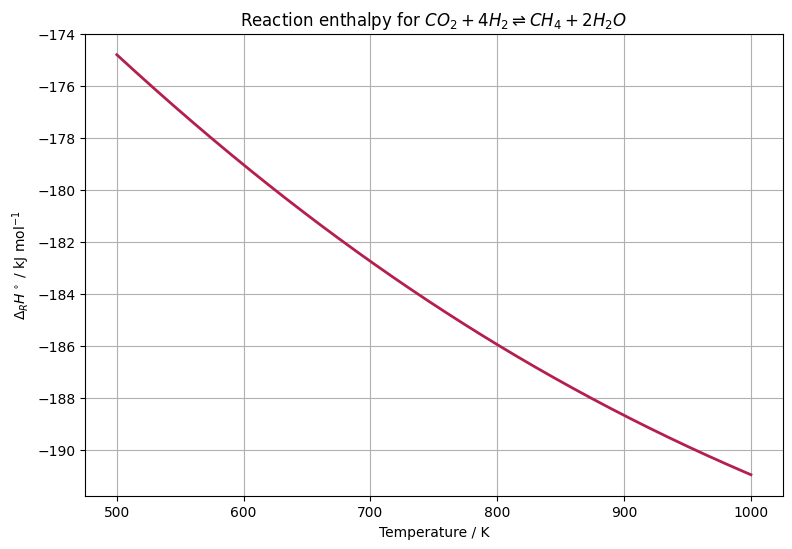

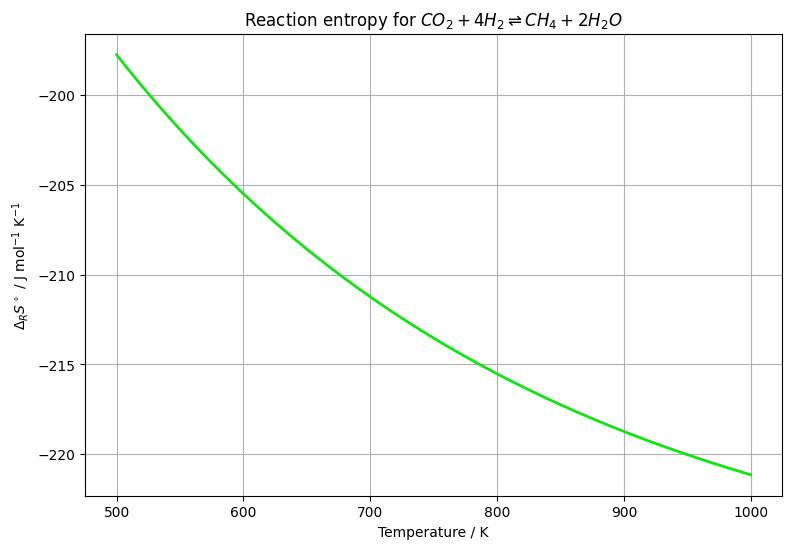

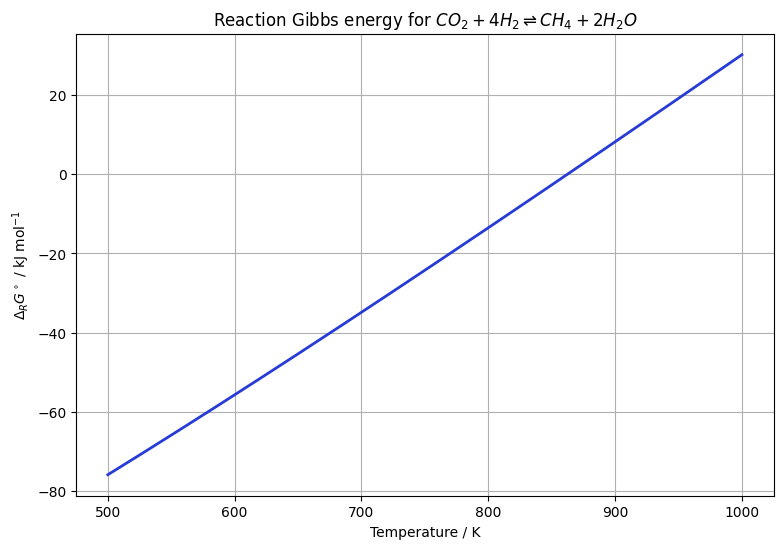

In [30]:
# Reaction:
# CO2 + 4 H2 <-> CH4 + 2 H2O


# common temperature range for all species in this reaction
T_min = 500      # K, because H2O data starts at 500 K
T_max = 1000     # K

T_range = np.linspace(T_min, T_max, 500)

# calculate reaction properties over full temperature range
dH_R = np.array([reaction_enthalpy(reaction_1, T) for T in T_range])
dS_R = np.array([reaction_entropy(reaction_1, T) for T in T_range])
dG_R = np.array([reaction_gibbs(reaction_1, T) for T in T_range])


# manually selected colors
color_H = "#b41f4e"   
color_S = "#11e511"  
color_G = "#273bd6"  


# Reaction enthalpy plot
plt.figure(figsize=(9, 6))
plt.plot(T_range, dH_R, color=color_H, linewidth=2)
plt.xlabel("Temperature / K")
plt.ylabel(r"$\Delta_R H^\circ$ / kJ mol$^{-1}$")
plt.title(r"Reaction enthalpy for $CO_2 + 4H_2 \rightleftharpoons CH_4 + 2H_2O$")
plt.grid(True)
plt.show()


# Reaction entropy plot
plt.figure(figsize=(9, 6))
plt.plot(T_range, dS_R, color=color_S, linewidth=2)
plt.xlabel("Temperature / K")
plt.ylabel(r"$\Delta_R S^\circ$ / J mol$^{-1}$ K$^{-1}$")
plt.title(r"Reaction entropy for $CO_2 + 4H_2 \rightleftharpoons CH_4 + 2H_2O$")
plt.grid(True)
plt.show()


# Reaction Gibbs energy plot
plt.figure(figsize=(9, 6))
plt.plot(T_range, dG_R, color=color_G, linewidth=2)
plt.xlabel("Temperature / K")
plt.ylabel(r"$\Delta_R G^\circ$ / kJ mol$^{-1}$")
plt.title(r"Reaction Gibbs energy for $CO_2 + 4H_2 \rightleftharpoons CH_4 + 2H_2O$")
plt.grid(True)
plt.show()